### Runtime comparison of LWF vs batched LWF

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from pyriemann.estimation import Covariances
from pcp_project.estimators import BatchCovariances, batch_ledoit_wolf

rng = np.random.default_rng(42)
X = rng.standard_normal((100, 32, 128))

ours = BatchCovariances(
    estimator=batch_ledoit_wolf, assume_centered=True, block_size=1000
)
theirs = Covariances(estimator="lwf", assume_centered=True, block_size=1000)

N = 1000

ours_times = np.empty(N)
theirs_times = np.empty(N)

for i in range(N):
    t0 = time.perf_counter()
    ours.fit_transform(X)
    ours_times[i] = time.perf_counter() - t0

for i in range(N):
    t0 = time.perf_counter()
    theirs.fit_transform(X)
    theirs_times[i] = time.perf_counter() - t0

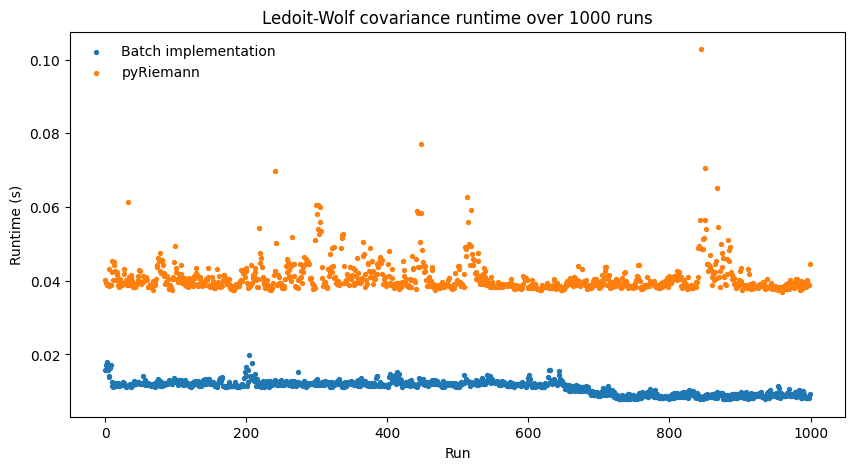

In [29]:
plt.figure(figsize=(10, 5))

plt.scatter(
    np.arange(N),
    ours_times,
    s=8,
    label="Batch implementation",
)

plt.scatter(
    np.arange(N),
    theirs_times,
    s=8,
    label="pyRiemann",
)

plt.xlabel("Run")
plt.ylabel("Runtime (s)")
plt.title("Ledoit-Wolf covariance runtime over 1000 runs")
plt.legend(frameon=False)

plt.show()

In [32]:
print("Average runtime")
print(f"Batch:      {ours_times.mean():.3f} s")
print(f"pyRiemann:  {theirs_times.mean():.3f} s")
print(f"Speedup:    {theirs_times.mean() / ours_times.mean():.2f}x")

Average runtime
Batch:      0.011 s
pyRiemann:  0.041 s
Speedup:    3.65x
